# U-Net Generator — Chest X-Ray LR→HR (Pix2Pix Generator, no discriminator yet)

Adapted from the C3W2A U-Net assignment. This notebook trains **only the Generator**:
`bicubic-upsampled low-res X-ray → real high-res X-ray`, using an L1 reconstruction loss.

Fixes applied vs. the original assignment code:
- `ExpandingBlock.forward` now actually `return`s its output (was a bare `return`).
- `UNet.forward` is completed (was truncated before `expand3`/`expand4`/`downfeature`).
- Convolutions now use `padding=1` so output spatial size == input spatial size (since your
  bicubic input and HR target are already the same resolution per pair — no crop-to-target needed).
- Output head uses `Tanh` (images normalized to [-1, 1]) instead of raw logits.
- Loss changed from `BCEWithLogitsLoss` → `L1Loss`.
- Dataset replaced with a paired `chest_xray_bicubic` (input) / `chest_xray` (target) loader,
  matched by relative path so files with the same name in different class folders don't collide.


## 1. Setup

In [10]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)


Using device: cuda


## 2. Get the dataset

Easiest path in Colab: use `kagglehub` to pull the dataset directly (no manual kaggle.json juggling).
If you already downloaded it elsewhere (e.g. Google Drive), skip this cell and just set `DATASET_ROOT` below.

In [13]:
!pip install -q kagglehub

import kagglehub
DATASET_ROOT = kagglehub.dataset_download("assemelqirsh/chest-x-ray-dataset")
print('Dataset downloaded to:', DATASET_ROOT)

# Sanity check: list top-level contents
for p in Path(DATASET_ROOT).iterdir():
    print(p)


Dataset downloaded to: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray_bicubic
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray_low_res


## 3. Config

Update `HR_DIRNAME` / `LR_DIRNAME` below if the actual folder names inside `DATASET_ROOT`
differ from what's shown in the cell above (they should be `chest_xray` and `chest_xray_bicubic`).

In [15]:
HR_DIRNAME = 'chest_xray'          # ground-truth high-res images (target)
LR_DIRNAME = 'chest_xray_bicubic'  # bicubic-upsampled low-res images (input)

hr_root = Path(DATASET_ROOT) / HR_DIRNAME
lr_root = Path(DATASET_ROOT) / LR_DIRNAME
assert hr_root.exists(), f'Could not find {hr_root} — check DATASET_ROOT contents above'
assert lr_root.exists(), f'Could not find {lr_root} — check DATASET_ROOT contents above'

input_dim = 1        # grayscale
label_dim = 1         # grayscale
hidden_channels = 64
image_size = 256      # both input and target get resized to this (square) size
n_epochs = 30
batch_size = 8
lr = 2e-4
display_step = 100
val_fraction = 0.1
checkpoint_path = '/content/unet_generator.pth'


## 4. Pair up LR-bicubic and HR files

Matches files by **relative path** (not just filename) so e.g. `train/NORMAL/x.jpeg` in
`chest_xray_bicubic` is paired with `train/NORMAL/x.jpeg` in `chest_xray`, avoiding filename
collisions across class/split subfolders. Any bicubic file without a matching HR file (or vice
versa) is skipped and reported.

## 5. Dataset / DataLoader

In [ ]:
class XrayPairDataset(Dataset):
    '''
    Returns (bicubic_lr_image, hr_image) tensors, both grayscale, both resized to
    (image_size, image_size), both normalized to [-1, 1] to match the generator's Tanh output.
    '''
    def __init__(self, pairs, image_size=256):
        self.pairs = pairs
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),                # -> [0, 1]
            transforms.Normalize(mean=[0.5], std=[0.5]),  # -> [-1, 1]
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        lr_img = Image.open(lr_path)
        hr_img = Image.open(hr_path)
        return self.transform(lr_img), self.transform(hr_img)


full_dataset = XrayPairDataset(pairs, image_size=image_size)

n_val = int(len(full_dataset) * val_fraction)
n_train = len(full_dataset) - n_val
train_dataset, val_dataset = random_split(
    full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0)
)
print(f'Train: {n_train} | Val: {n_val}')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


In [ ]:
def show_tensor_images(image_tensor, num_images=8, size=(1, image_size, image_size)):
    '''
    Visualizes a batch of images normalized to [-1, 1] by rescaling back to [0, 1] for display.
    '''
    image_unflat = ((image_tensor.detach().cpu() + 1) / 2).clamp(0, 1).view(-1, *size)
    image_grid = make_grid(image_unflat[:num_images], nrow=4)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

# Quick look at a sample pair
lr_sample, hr_sample = full_dataset[0]
print('LR shape:', lr_sample.shape, '| HR shape:', hr_sample.shape)
show_tensor_images(torch.stack([lr_sample, hr_sample]), num_images=2)


## 6. U-Net building blocks

In [ ]:
class ContractingBlock(nn.Module):
    '''
    Two 3x3 convolutions (padded, so spatial size is preserved) + ReLU, then 2x2 max pool.
    '''
    def __init__(self, input_channels):
        super(ContractingBlock, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, input_channels * 2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(input_channels * 2, input_channels * 2, kernel_size=3, padding=1)
        self.activation = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        x = self.maxpool(x)
        return x


In [ ]:
def crop(image, new_shape):
    '''
    Center-crops `image` to `new_shape`. Kept as a safety net for the skip connections —
    with padded convolutions and even input sizes this should be a no-op (shapes already match),
    but it protects against any off-by-one mismatch from odd input dimensions.
    '''
    middle_height = image.shape[2] // 2
    middle_width = image.shape[3] // 2
    starting_height = middle_height - new_shape[2] // 2
    final_height = starting_height + new_shape[2]
    starting_width = middle_width - new_shape[3] // 2
    final_width = starting_width + new_shape[3]
    return image[:, :, starting_height:final_height, starting_width:final_width]


In [ ]:
class ExpandingBlock(nn.Module):
    '''
    Upsample -> 2x2 up-conv (halves channels) -> concat with cropped skip connection
    -> two padded 3x3 convolutions + ReLU.
    '''
    def __init__(self, input_channels):
        super(ExpandingBlock, self).__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = nn.Conv2d(input_channels, input_channels // 2, kernel_size=2, stride=1, padding='same')
        self.conv2 = nn.Conv2d(input_channels, input_channels // 2, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(input_channels // 2, input_channels // 2, kernel_size=3, stride=1, padding=1)
        self.activation = nn.ReLU()

    def forward(self, x, skip_con_x):
        x = self.upsample(x)
        x = self.conv1(x)
        skip_con_x = crop(skip_con_x, x.shape)
        x = torch.cat([x, skip_con_x], axis=1)
        x = self.activation(self.conv2(x))
        x = self.activation(self.conv3(x))
        return x


In [ ]:
class FeatureMapBlock(nn.Module):
    '''
    1x1 convolution mapping to the desired number of output channels.
    Set final_layer=True to also apply a Tanh (for the last layer of the generator,
    since images are normalized to [-1, 1]).
    '''
    def __init__(self, input_channels, output_channels, final_layer=False):
        super(FeatureMapBlock, self).__init__()
        self.conv = nn.Conv2d(input_channels, output_channels, kernel_size=1)
        self.final_layer = final_layer
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.conv(x)
        if self.final_layer:
            x = self.activation(x)
        return x


In [ ]:
class UNet(nn.Module):
    '''
    4 contracting blocks + 4 expanding blocks, with an upfeature layer at the start
    and a downfeature (Tanh) layer at the end.
    '''
    def __init__(self, input_channels, output_channels, hidden_channels=64):
        super(UNet, self).__init__()
        self.upfeature = FeatureMapBlock(input_channels, hidden_channels)
        self.contract1 = ContractingBlock(hidden_channels)
        self.contract2 = ContractingBlock(hidden_channels * 2)
        self.contract3 = ContractingBlock(hidden_channels * 4)
        self.contract4 = ContractingBlock(hidden_channels * 8)
        self.expand1 = ExpandingBlock(hidden_channels * 16)
        self.expand2 = ExpandingBlock(hidden_channels * 8)
        self.expand3 = ExpandingBlock(hidden_channels * 4)
        self.expand4 = ExpandingBlock(hidden_channels * 2)
        self.downfeature = FeatureMapBlock(hidden_channels, output_channels, final_layer=True)

    def forward(self, x):
        x0 = self.upfeature(x)
        x1 = self.contract1(x0)
        x2 = self.contract2(x1)
        x3 = self.contract3(x2)
        x4 = self.contract4(x3)
        x5 = self.expand1(x4, x3)
        x6 = self.expand2(x5, x2)
        x7 = self.expand3(x6, x1)
        x8 = self.expand4(x7, x0)
        xn = self.downfeature(x8)
        return xn


In [ ]:
# Sanity check: output shape should equal input shape (since we're doing same-size restoration)
test_unet = UNet(input_dim, label_dim, hidden_channels).to(device)
test_in = torch.randn(2, input_dim, image_size, image_size).to(device)
test_out = test_unet(test_in)
print('Input shape :', test_in.shape)
print('Output shape:', test_out.shape)
assert test_out.shape == test_in.shape, 'Output must match input spatial size for this pipeline'
print('OK — shapes match')
del test_unet, test_in, test_out


## 7. Loss, metrics, model/optimizer

In [ ]:
def psnr(pred, target, max_val=2.0):
    '''
    PSNR computed on the [-1, 1]-normalized tensors directly (max_val=2.0 covers that range).
    Higher is better.
    '''
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return float('inf')
    return 10 * torch.log10((max_val ** 2) / mse)


unet = UNet(input_dim, label_dim, hidden_channels).to(device)
unet_opt = torch.optim.Adam(unet.parameters(), lr=lr)
criterion = nn.L1Loss()


## 8. Training loop

In [ ]:
train()


In [ ]:
print(checkpoint_path)
import shutil
shutil.copy(checkpoint_path, '/kaggle/working/unet_generator.pth')

In [ ]:
import os, time
print(os.path.exists(checkpoint_path))
print(time.ctime(os.path.getmtime(checkpoint_path)))

In [ ]:
def validate():
    unet.eval()
    total_loss, total_psnr, n_batches = 0.0, 0.0, 0
    with torch.no_grad():
        for lr_img, hr_img in val_loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            pred = unet(lr_img)
            total_loss += criterion(pred, hr_img).item()
            total_psnr += psnr(pred, hr_img).item()
            n_batches += 1
    unet.train()
    return total_loss / n_batches, total_psnr / n_batches


def train():
    cur_step = 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        for lr_img, hr_img in tqdm(train_loader, desc=f'Epoch {epoch}'):
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)

            unet_opt.zero_grad()
            pred = unet(lr_img)
            loss = criterion(pred, hr_img)
            loss.backward()
            unet_opt.step()

            if cur_step % display_step == 0:
                print(f'Epoch {epoch} | Step {cur_step} | L1 loss: {loss.item():.4f}')
                show_tensor_images(lr_img, num_images=4)   # input (bicubic, blurry)
                show_tensor_images(hr_img, num_images=4)   # target (real HR)
                show_tensor_images(pred, num_images=4)     # generator output
            cur_step += 1

        val_loss, val_psnr = validate()
        train_losses.append(loss.item())
        val_losses.append(val_loss)
        print(f'== Epoch {epoch} done | train L1: {loss.item():.4f} | val L1: {val_loss:.4f} | val PSNR: {val_psnr:.2f} dB ==')

        torch.save({'epoch': epoch, 'model_state_dict': unet.state_dict(),
                    'optimizer_state_dict': unet_opt.state_dict()}, checkpoint_path)

    plt.figure()
    plt.plot(train_losses, label='train L1 (last batch/epoch)')
    plt.plot(val_losses, label='val L1')
    plt.xlabel('epoch'); plt.ylabel('L1 loss'); plt.legend(); plt.show()


In [ ]:
# Load the trained generator
unet_test = UNet(input_dim, label_dim, hidden_channels).to(device)
ckpt = torch.load(checkpoint_path, map_location=device)
unet_test.load_state_dict(ckpt['model_state_dict'])
unet_test.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

# Run on a batch from the validation set and visualize input / output / target side by side
lr_batch, hr_batch = next(iter(val_loader))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

with torch.no_grad():
    pred_batch = unet_test(lr_batch)

print("Input (bicubic, blurry):")
show_tensor_images(lr_batch, num_images=4)
print("Generator output:")
show_tensor_images(pred_batch, num_images=4)
print("Ground truth (real HR):")
show_tensor_images(hr_batch, num_images=4)

# Quantitative check on the whole val set
test_loss, test_psnr = validate()
print(f"Val L1: {test_loss:.4f} | Val PSNR: {test_psnr:.2f} dB")

In [ ]:
lr_batch, hr_batch = next(iter(val_loader))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
baseline_psnr = psnr(lr_batch, hr_batch)
print(f"Bicubic-only PSNR (no model): {baseline_psnr:.2f} dB")

In [ ]:
total_baseline_psnr, n = 0.0, 0
with torch.no_grad():
    for lr_img, hr_img in val_loader:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        total_baseline_psnr += psnr(lr_img, hr_img).item()
        n += 1
print(f"Bicubic-only PSNR (full val set): {total_baseline_psnr/n:.2f} dB")

In [ ]:
from IPython.display import FileLink
FileLink(checkpoint_path)
/kaggle/working/unet_generator.pth

In [ ]:
import shutil
shutil.make_archive('/kaggle/working/unet_generator', 'zip', root_dir='/kaggle/working', base_dir='unet_generator.pth')

In [29]:
from pathlib import Path

# Your enhanced (VAE-denoised → bicubic) images — this is the fine-tune INPUT
vae_bicubic_dir = Path("/kaggle/input/datasets/raghavvbhat/enhanced-zip-images-from-vae-model/enhanced_images")

# Original chest-xray-pneumonia dataset — this is where the fine-tune TARGET (HR) comes from
pneumonia_root = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia")

# You said the enhanced images only cover test/NORMAL, so match against that subset
finetune_hr_root = pneumonia_root / "chest_xray" / "test" / "NORMAL"

# Sanity check both directories actually resolve before going further
assert vae_bicubic_dir.exists(), f"Not found: {vae_bicubic_dir}"
assert finetune_hr_root.exists(), f"Not found: {finetune_hr_root} — check the folder structure below"

print("Sample enhanced files:", list(vae_bicubic_dir.iterdir())[:5])
print("Sample HR files:", list(finetune_hr_root.iterdir())[:5])

Sample enhanced files: [PosixPath('/kaggle/input/datasets/raghavvbhat/enhanced-zip-images-from-vae-model/enhanced_images/NORMAL2-IM-0336-0001.jpeg'), PosixPath('/kaggle/input/datasets/raghavvbhat/enhanced-zip-images-from-vae-model/enhanced_images/IM-0101-0001.jpeg'), PosixPath('/kaggle/input/datasets/raghavvbhat/enhanced-zip-images-from-vae-model/enhanced_images/NORMAL2-IM-0337-0001.jpeg'), PosixPath('/kaggle/input/datasets/raghavvbhat/enhanced-zip-images-from-vae-model/enhanced_images/NORMAL2-IM-0198-0001.jpeg'), PosixPath('/kaggle/input/datasets/raghavvbhat/enhanced-zip-images-from-vae-model/enhanced_images/IM-0013-0001.jpeg')]
Sample HR files: [PosixPath('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0336-0001.jpeg'), PosixPath('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0101-0001.jpeg'), PosixPath('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL

In [31]:
IMG_EXTS = {'.jpeg', '.jpg', '.png'}

ft_lr_files = {p.name: p for p in vae_bicubic_dir.iterdir() if p.suffix.lower() in IMG_EXTS}
ft_hr_files = {p.name: p for p in finetune_hr_root.iterdir() if p.suffix.lower() in IMG_EXTS}

ft_common = sorted(set(ft_lr_files) & set(ft_hr_files))
missing_hr = set(ft_lr_files) - set(ft_hr_files)
missing_lr = set(ft_hr_files) - set(ft_lr_files)

print(f'Enhanced files found : {len(ft_lr_files)}')
print(f'HR files found       : {len(ft_hr_files)}')
print(f'Matched pairs        : {len(ft_common)}')
print(f'Enhanced w/o HR match: {len(missing_hr)}')
print(f'HR w/o enhanced match: {len(missing_lr)}')

ft_pairs = [(ft_lr_files[k], ft_hr_files[k]) for k in ft_common]
assert len(ft_pairs) > 0, 'No matches — check filenames above'

Enhanced files found : 234
HR files found       : 234
Matched pairs        : 234
Enhanced w/o HR match: 0
HR w/o enhanced match: 0


In [32]:
ft_dataset = XrayPairDataset(ft_pairs, image_size=image_size)
n_ft_val = max(1, int(len(ft_dataset) * 0.15))
n_ft_train = len(ft_dataset) - n_ft_val
ft_train_ds, ft_val_ds = random_split(ft_dataset, [n_ft_train, n_ft_val], generator=torch.Generator().manual_seed(0))
print(f'Fine-tune train: {n_ft_train} | val: {n_ft_val}')

ft_train_loader = DataLoader(ft_train_ds, batch_size=4, shuffle=True, num_workers=2)
ft_val_loader = DataLoader(ft_val_ds, batch_size=4, shuffle=False, num_workers=2)

unet_ft = UNet(input_dim, label_dim, hidden_channels).to(device)
ckpt = torch.load(checkpoint_path, map_location=device)
unet_ft.load_state_dict(ckpt['model_state_dict'])
print(f"Starting fine-tune from epoch {ckpt['epoch']} checkpoint")

ft_opt = torch.optim.Adam(unet_ft.parameters(), lr=2e-5)
ft_epochs = 8
ft_checkpoint_path = '/kaggle/working/unet_generator_finetuned.pth'
best_ft_val_loss = float('inf')

for epoch in range(ft_epochs):
    unet_ft.train()
    for lr_img, hr_img in ft_train_loader:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        ft_opt.zero_grad()
        pred = unet_ft(lr_img)
        loss = criterion(pred, hr_img)
        loss.backward()
        ft_opt.step()

    unet_ft.eval()
    val_loss, val_psnr_val = 0.0, 0.0
    with torch.no_grad():
        for lr_img, hr_img in ft_val_loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            pred = unet_ft(lr_img)
            val_loss += criterion(pred, hr_img).item()
            val_psnr_val += psnr(pred, hr_img).item()
    val_loss /= len(ft_val_loader)
    val_psnr_val /= len(ft_val_loader)
    print(f'FT Epoch {epoch} | train L1: {loss.item():.4f} | val L1: {val_loss:.4f} | val PSNR: {val_psnr_val:.2f} dB')

    if val_loss < best_ft_val_loss:
        best_ft_val_loss = val_loss
        torch.save({'epoch': epoch, 'model_state_dict': unet_ft.state_dict()}, ft_checkpoint_path)
        print(f'  -> new best, saved to {ft_checkpoint_path}')

Fine-tune train: 199 | val: 35
Starting fine-tune from epoch 13 checkpoint
FT Epoch 0 | train L1: 0.1047 | val L1: 0.0994 | val PSNR: 23.73 dB
  -> new best, saved to /kaggle/working/unet_generator_finetuned.pth
FT Epoch 1 | train L1: 0.0857 | val L1: 0.0839 | val PSNR: 25.10 dB
  -> new best, saved to /kaggle/working/unet_generator_finetuned.pth
FT Epoch 2 | train L1: 0.0622 | val L1: 0.0674 | val PSNR: 26.94 dB
  -> new best, saved to /kaggle/working/unet_generator_finetuned.pth
FT Epoch 3 | train L1: 0.0704 | val L1: 0.0615 | val PSNR: 27.73 dB
  -> new best, saved to /kaggle/working/unet_generator_finetuned.pth
FT Epoch 4 | train L1: 0.0566 | val L1: 0.0600 | val PSNR: 27.95 dB
  -> new best, saved to /kaggle/working/unet_generator_finetuned.pth
FT Epoch 5 | train L1: 0.0558 | val L1: 0.0638 | val PSNR: 27.49 dB
FT Epoch 6 | train L1: 0.0543 | val L1: 0.0541 | val PSNR: 28.70 dB
  -> new best, saved to /kaggle/working/unet_generator_finetuned.pth
FT Epoch 7 | train L1: 0.0604 | val

VAE-enhanced input:


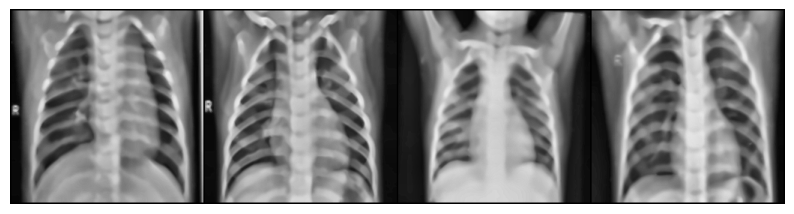

Fine-tuned model output:


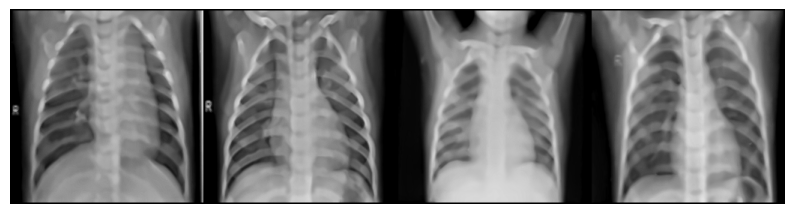

Real HR target:


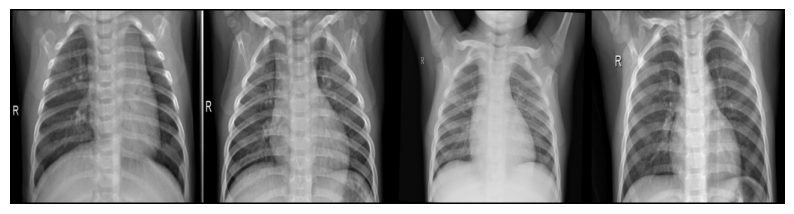

In [34]:
lr_ft_batch, hr_ft_batch = next(iter(ft_val_loader))
lr_ft_batch, hr_ft_batch = lr_ft_batch.to(device), hr_ft_batch.to(device)
with torch.no_grad():
    pred_ft_batch = unet_ft(lr_ft_batch)

print("VAE-enhanced input:")
show_tensor_images(lr_ft_batch, num_images=4)
print("Fine-tuned model output:")
show_tensor_images(pred_ft_batch, num_images=4)
print("Real HR target:")
show_tensor_images(hr_ft_batch, num_images=4)

VAE-enhanced input (what the model receives):


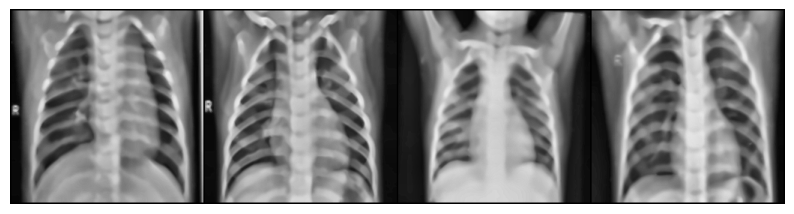

Fine-tuned model output:


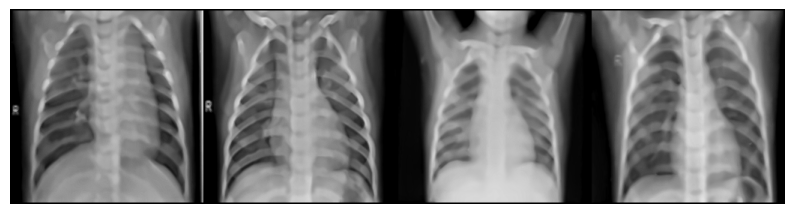

Real HR target (ground truth):


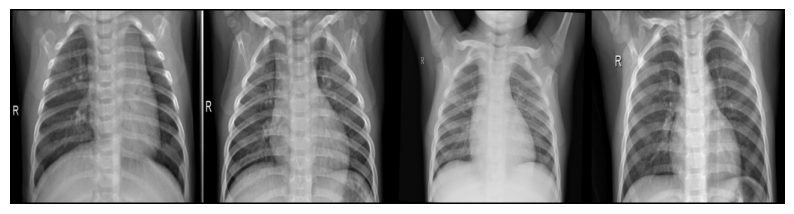

In [35]:
unet_ft.eval()
lr_ft_batch, hr_ft_batch = next(iter(ft_val_loader))
lr_ft_batch, hr_ft_batch = lr_ft_batch.to(device), hr_ft_batch.to(device)

with torch.no_grad():
    pred_ft_batch = unet_ft(lr_ft_batch)

print("VAE-enhanced input (what the model receives):")
show_tensor_images(lr_ft_batch, num_images=4)

print("Fine-tuned model output:")
show_tensor_images(pred_ft_batch, num_images=4)

print("Real HR target (ground truth):")
show_tensor_images(hr_ft_batch, num_images=4)

In [36]:
unet_ft = UNet(input_dim, label_dim, hidden_channels).to(device)
ckpt_ft = torch.load(ft_checkpoint_path, map_location=device)
unet_ft.load_state_dict(ckpt_ft['model_state_dict'])
unet_ft.eval()
print(f"Loaded fine-tuned checkpoint from epoch {ckpt_ft['epoch']}")

Loaded fine-tuned checkpoint from epoch 6


In [39]:
GEN_CHECKPOINT_PATH = '/kaggle/working/unet_generator.pth'  # <-- update if different
GAN_CHECKPOINT_PATH = '/kaggle/working/pix2pix_gan.pth'

lambda_recon = 100
gan_lr = 2e-4
gan_epochs = 20
disc_hidden_channels = 64

adv_criterion = nn.BCEWithLogitsLoss()
recon_criterion = nn.L1Loss()

In [41]:
class DiscriminatorBlock(nn.Module):
    def __init__(self, input_channels, output_channels, use_norm=True, stride=2):
        super().__init__()
        layers = [nn.Conv2d(input_channels, output_channels, kernel_size=4, stride=stride, padding=1)]
        if use_norm:
            layers.append(nn.InstanceNorm2d(output_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class PatchDiscriminator(nn.Module):
    def __init__(self, input_channels, hidden_channels=64):
        super().__init__()
        self.d1 = DiscriminatorBlock(input_channels, hidden_channels, use_norm=False)
        self.d2 = DiscriminatorBlock(hidden_channels, hidden_channels * 2)
        self.d3 = DiscriminatorBlock(hidden_channels * 2, hidden_channels * 4)
        self.d4 = DiscriminatorBlock(hidden_channels * 4, hidden_channels * 8, stride=1)
        self.final = nn.Conv2d(hidden_channels * 8, 1, kernel_size=4, stride=1, padding=1)

    def forward(self, x, y):
        combined = torch.cat([x, y], dim=1)
        h = self.d1(combined)
        h = self.d2(h)
        h = self.d3(h)
        h = self.d4(h)
        return self.final(h)

In [42]:
gen = UNet(input_dim, label_dim, hidden_channels).to(device)
gen_ckpt = torch.load(GEN_CHECKPOINT_PATH, map_location=device)
gen.load_state_dict(gen_ckpt['model_state_dict'])
print(f"Loaded generator from epoch {gen_ckpt['epoch']}")

disc = PatchDiscriminator(input_dim + label_dim, disc_hidden_channels).to(device)

gen_opt = torch.optim.Adam(gen.parameters(), lr=gan_lr, betas=(0.5, 0.999))
disc_opt = torch.optim.Adam(disc.parameters(), lr=gan_lr, betas=(0.5, 0.999))

with torch.no_grad():
    test_x = torch.randn(2, input_dim, image_size, image_size).to(device)
    test_y = torch.randn(2, label_dim, image_size, image_size).to(device)
    test_patch_out = disc(test_x, test_y)
print('Discriminator patch output shape:', test_patch_out.shape)
del test_x, test_y, test_patch_out

Loaded generator from epoch 13
Discriminator patch output shape: torch.Size([2, 1, 30, 30])


In [49]:
def gen_loss_fn(gen, disc, lr_img, hr_img):
    fake_hr = gen(lr_img)
    disc_fake_pred = disc(lr_img, fake_hr)
    gen_adv_loss = adv_criterion(disc_fake_pred, torch.ones_like(disc_fake_pred))
    gen_recon_loss = recon_criterion(fake_hr, hr_img)
    total_gen_loss = gen_adv_loss + lambda_recon * gen_recon_loss
    return total_gen_loss, gen_adv_loss, gen_recon_loss, fake_hr


def disc_loss_fn(disc, lr_img, hr_img, fake_hr):
    disc_fake_pred = disc(lr_img, fake_hr.detach())
    disc_fake_loss = adv_criterion(disc_fake_pred, torch.zeros_like(disc_fake_pred))
    disc_real_pred = disc(lr_img, hr_img)
    disc_real_loss = adv_criterion(disc_real_pred, torch.ones_like(disc_real_pred))
    return (disc_fake_loss + disc_real_loss) / 2


def validate_gan():
    gen.eval()
    total_l1, total_psnr, n_batches = 0.0, 0.0, 0
    with torch.no_grad():
        for lr_img, hr_img in val_loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            pred = gen(lr_img)
            total_l1 += recon_criterion(pred, hr_img).item()
            total_psnr += psnr(pred, hr_img).item()
            n_batches += 1
    gen.train()
    return total_l1 / n_batches, total_psnr / n_batches

In [50]:
def train_gan():
    cur_step = 0
    best_val_l1 = float('inf')

    for epoch in range(gan_epochs):
        for lr_img, hr_img in tqdm(train_loader, desc=f'GAN Epoch {epoch}'):
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)

            disc_opt.zero_grad()
            with torch.no_grad():
                fake_hr = gen(lr_img)
            d_loss = disc_loss_fn(disc, lr_img, hr_img, fake_hr)
            d_loss.backward()
            disc_opt.step()

            gen_opt.zero_grad()
            g_loss, g_adv, g_recon, fake_hr = gen_loss_fn(gen, disc, lr_img, hr_img)
            g_loss.backward()
            gen_opt.step()

            if cur_step % display_step == 0:
                print(f'Epoch {epoch} | Step {cur_step} | D loss: {d_loss.item():.4f} | '
                      f'G total: {g_loss.item():.4f} (adv: {g_adv.item():.4f}, L1: {g_recon.item():.4f})')
                show_tensor_images(lr_img, num_images=4)
                show_tensor_images(fake_hr, num_images=4)
                show_tensor_images(hr_img, num_images=4)
            cur_step += 1

        val_l1, val_psnr = validate_gan()
        print(f'== GAN Epoch {epoch} done | val L1: {val_l1:.4f} | val PSNR: {val_psnr:.2f} dB ==')

        if val_l1 < best_val_l1:
            best_val_l1 = val_l1
            torch.save({'epoch': epoch,
                        'gen_state_dict': gen.state_dict(),
                        'disc_state_dict': disc.state_dict(),
                        'gen_opt_state_dict': gen_opt.state_dict(),
                        'disc_opt_state_dict': disc_opt.state_dict()}, GAN_CHECKPOINT_PATH)
            print(f'  -> new best (val L1 {val_l1:.4f}), saved to {GAN_CHECKPOINT_PATH}')

In [4]:
import os
print(os.path.exists('/kaggle/working/pix2pix_gan.pth'))

False


In [11]:
BASE_GEN_PATH = '/kaggle/input/models/raghavvbhat/unet-genrator/pytorch/default/1/unet_generator.pth'

# Re-run: imports, XrayPairDataset class, UNet class, ContractingBlock/ExpandingBlock/FeatureMapBlock,
# show_tensor_images, psnr, criterion, device, image_size, input_dim, label_dim, hidden_channels
# (paste those definition cells from Part 1 again — they're gone after the session reset)

In [6]:
import kagglehub
pneumonia_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
pneumonia_root = Path(pneumonia_path)

train_normal_root = pneumonia_root / "chest_xray" / "train" / "NORMAL"
assert train_normal_root.exists(), f"Not found: {train_normal_root}"
print("Sample HR files:", list(train_normal_root.iterdir())[:3])

Sample HR files: [PosixPath('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-0771-0001.jpeg'), PosixPath('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-1294-0001-0002.jpeg'), PosixPath('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0675-0001.jpeg')]


In [12]:
IMG_EXTS = {'.jpeg', '.jpg', '.png'}

In [8]:
for name in ['IMG_EXTS', 'XrayPairDataset', 'UNet', 'show_tensor_images', 'psnr',
             'device', 'image_size', 'input_dim', 'label_dim', 'hidden_channels',
             'ContractingBlock', 'ExpandingBlock', 'FeatureMapBlock', 'crop',
             'PatchDiscriminator', 'DiscriminatorBlock']:
    print(name, name in dir())

IMG_EXTS True
XrayPairDataset False
UNet False
show_tensor_images False
psnr False
device False
image_size False
input_dim False
label_dim False
hidden_channels False
ContractingBlock False
ExpandingBlock False
FeatureMapBlock False
crop False
PatchDiscriminator False
DiscriminatorBlock False


In [22]:
class ContractingBlock(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, input_channels * 2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(input_channels * 2, input_channels * 2, kernel_size=3, padding=1)
        self.activation = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        x = self.maxpool(x)
        return x


def crop(image, new_shape):
    middle_height = image.shape[2] // 2
    middle_width = image.shape[3] // 2
    starting_height = middle_height - new_shape[2] // 2
    final_height = starting_height + new_shape[2]
    starting_width = middle_width - new_shape[3] // 2
    final_width = starting_width + new_shape[3]
    return image[:, :, starting_height:final_height, starting_width:final_width]


class ExpandingBlock(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = nn.Conv2d(input_channels, input_channels // 2, kernel_size=2, stride=1, padding='same')
        self.conv2 = nn.Conv2d(input_channels, input_channels // 2, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(input_channels // 2, input_channels // 2, kernel_size=3, stride=1, padding=1)
        self.activation = nn.ReLU()

    def forward(self, x, skip_con_x):
        x = self.upsample(x)
        x = self.conv1(x)
        skip_con_x = crop(skip_con_x, x.shape)
        x = torch.cat([x, skip_con_x], axis=1)
        x = self.activation(self.conv2(x))
        x = self.activation(self.conv3(x))
        return x


class FeatureMapBlock(nn.Module):
    def __init__(self, input_channels, output_channels, final_layer=False):
        super().__init__()
        self.conv = nn.Conv2d(input_channels, output_channels, kernel_size=1)
        self.final_layer = final_layer
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.conv(x)
        if self.final_layer:
            x = self.activation(x)
        return x


class UNet(nn.Module):
    def __init__(self, input_channels, output_channels, hidden_channels=64):
        super().__init__()
        self.upfeature = FeatureMapBlock(input_channels, hidden_channels)
        self.contract1 = ContractingBlock(hidden_channels)
        self.contract2 = ContractingBlock(hidden_channels * 2)
        self.contract3 = ContractingBlock(hidden_channels * 4)
        self.contract4 = ContractingBlock(hidden_channels * 8)
        self.expand1 = ExpandingBlock(hidden_channels * 16)
        self.expand2 = ExpandingBlock(hidden_channels * 8)
        self.expand3 = ExpandingBlock(hidden_channels * 4)
        self.expand4 = ExpandingBlock(hidden_channels * 2)
        self.downfeature = FeatureMapBlock(hidden_channels, output_channels, final_layer=True)

    def forward(self, x):
        x0 = self.upfeature(x)
        x1 = self.contract1(x0)
        x2 = self.contract2(x1)
        x3 = self.contract3(x2)
        x4 = self.contract4(x3)
        x5 = self.expand1(x4, x3)
        x6 = self.expand2(x5, x2)
        x7 = self.expand3(x6, x1)
        x8 = self.expand4(x7, x0)
        return self.downfeature(x8)

In [23]:
class XrayPairDataset(Dataset):
    def __init__(self, pairs, image_size=256):
        self.pairs = pairs
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        return self.transform(Image.open(lr_path)), self.transform(Image.open(hr_path))


def show_tensor_images(image_tensor, num_images=8, size=(1, image_size, image_size)):
    image_unflat = ((image_tensor.detach().cpu() + 1) / 2).clamp(0, 1).view(-1, *size)
    image_grid = make_grid(image_unflat[:num_images], nrow=4)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()


def psnr(pred, target, max_val=2.0):
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return float('inf')
    return 10 * torch.log10((max_val ** 2) / mse)

In [24]:
class DiscriminatorBlock(nn.Module):
    def __init__(self, input_channels, output_channels, use_norm=True, stride=2):
        super().__init__()
        layers = [nn.Conv2d(input_channels, output_channels, kernel_size=4, stride=stride, padding=1)]
        if use_norm:
            layers.append(nn.InstanceNorm2d(output_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class PatchDiscriminator(nn.Module):
    def __init__(self, input_channels, hidden_channels=64):
        super().__init__()
        self.d1 = DiscriminatorBlock(input_channels, hidden_channels, use_norm=False)
        self.d2 = DiscriminatorBlock(hidden_channels, hidden_channels * 2)
        self.d3 = DiscriminatorBlock(hidden_channels * 2, hidden_channels * 4)
        self.d4 = DiscriminatorBlock(hidden_channels * 4, hidden_channels * 8, stride=1)
        self.final = nn.Conv2d(hidden_channels * 8, 1, kernel_size=4, stride=1, padding=1)

    def forward(self, x, y):
        combined = torch.cat([x, y], dim=1)
        h = self.d1(combined)
        h = self.d2(h)
        h = self.d3(h)
        h = self.d4(h)
        return self.final(h)

In [25]:
from pathlib import Path
vae_dir_v2 = Path("/kaggle/input/datasets/raghavvbhat/enhanced-images/enhanced_images")
train_normal_root = pneumonia_root / "chest_xray" / "train" / "NORMAL"

lr2_files = {p.name: p for p in vae_dir_v2.iterdir() if p.suffix.lower() in IMG_EXTS}
hr2_files = {p.name: p for p in train_normal_root.iterdir() if p.suffix.lower() in IMG_EXTS}
common2 = sorted(set(lr2_files) & set(hr2_files))
print(f'Matched: {len(common2)} | LR-only: {len(set(lr2_files)-set(hr2_files))} | HR-only: {len(set(hr2_files)-set(lr2_files))}')
pairs2 = [(lr2_files[k], hr2_files[k]) for k in common2]

Matched: 1341 | LR-only: 0 | HR-only: 0


In [26]:
ds2 = XrayPairDataset(pairs2, image_size=image_size)
n_val2 = max(1, int(len(ds2) * 0.15))
n_train2 = len(ds2) - n_val2
train_ds2, val_ds2 = random_split(ds2, [n_train2, n_val2], generator=torch.Generator().manual_seed(0))
train_loader2 = DataLoader(train_ds2, batch_size=4, shuffle=True, num_workers=2)
val_loader2 = DataLoader(val_ds2, batch_size=4, shuffle=False, num_workers=2)

In [27]:
GAN_V2_PATH = '/kaggle/working/pix2pix_gan_v2.pth'

gen2 = UNet(input_dim, label_dim, hidden_channels).to(device)
base_ckpt = torch.load(BASE_GEN_PATH, map_location=device)
gen2.load_state_dict(base_ckpt['model_state_dict'])
print(f"Warm-started generator from base model, epoch {base_ckpt['epoch']}")

disc2 = PatchDiscriminator(input_dim + label_dim, disc_hidden_channels).to(device)  # fresh, no prior GAN weights to load

gen_opt2 = torch.optim.Adam(gen2.parameters(), lr=1e-5, betas=(0.5, 0.999))
disc_opt2 = torch.optim.Adam(disc2.parameters(), lr=2e-6, betas=(0.5, 0.999))
adv_criterion = nn.BCEWithLogitsLoss()
recon_criterion = nn.L1Loss()
lambda_recon = 100

Warm-started generator from base model, epoch 13


In [17]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

input_dim = 1
label_dim = 1
hidden_channels = 64
image_size = 256
display_step = 100

Using device: cuda


In [37]:
disc_hidden_channels = 64
adv_criterion = nn.BCEWithLogitsLoss()
recon_criterion = nn.L1Loss()
lambda_recon = 100

In [38]:
def gen_loss_fn(gen, disc, lr_img, hr_img):
    fake_hr = gen(lr_img)
    disc_fake_pred = disc(lr_img, fake_hr)
    gen_adv_loss = adv_criterion(disc_fake_pred, torch.ones_like(disc_fake_pred))
    gen_recon_loss = recon_criterion(fake_hr, hr_img)
    total_gen_loss = gen_adv_loss + lambda_recon * gen_recon_loss
    return total_gen_loss, gen_adv_loss, gen_recon_loss, fake_hr


def disc_loss_fn(disc, lr_img, hr_img, fake_hr):
    disc_fake_pred = disc(lr_img, fake_hr.detach())
    disc_fake_loss = adv_criterion(disc_fake_pred, torch.zeros_like(disc_fake_pred))
    disc_real_pred = disc(lr_img, hr_img)
    disc_real_loss = adv_criterion(disc_real_pred, torch.ones_like(disc_real_pred))
    return (disc_fake_loss + disc_real_loss) / 2


def train_gan_v2(epochs=10):
    best_val_l1 = float('inf')
    cur_step = 0
    for epoch in range(epochs):
        for lr_img, hr_img in tqdm(train_loader2, desc=f'FT-GAN Epoch {epoch}'):
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)

            disc_opt2.zero_grad()
            with torch.no_grad():
                fake_hr = gen2(lr_img)
            d_loss = disc_loss_fn(disc2, lr_img, hr_img, fake_hr)
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(disc2.parameters(), max_norm=1.0)
            disc_opt2.step()

            gen_opt2.zero_grad()
            g_loss, g_adv, g_recon, fake_hr = gen_loss_fn(gen2, disc2, lr_img, hr_img)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(gen2.parameters(), max_norm=1.0)
            gen_opt2.step()

            if cur_step % 50 == 0:
                print(f'Ep{epoch} Step{cur_step} | D:{d_loss.item():.4f} | G:{g_loss.item():.4f} (adv:{g_adv.item():.4f}, L1:{g_recon.item():.4f})')
            cur_step += 1

        gen2.eval()
        val_l1, val_psnr_sum, n = 0.0, 0.0, 0
        with torch.no_grad():
            for lr_img, hr_img in val_loader2:
                lr_img, hr_img = lr_img.to(device), hr_img.to(device)
                pred = gen2(lr_img)
                val_l1 += recon_criterion(pred, hr_img).item()
                val_psnr_sum += psnr(pred, hr_img).item()
                n += 1
        val_l1 /= n; val_psnr_sum /= n
        gen2.train()
        print(f'== Epoch {epoch} | val L1: {val_l1:.4f} | val PSNR: {val_psnr_sum:.2f} dB ==')

        if val_l1 < best_val_l1:
            best_val_l1 = val_l1
            torch.save({'epoch': epoch, 'gen_state_dict': gen2.state_dict(),
                        'disc_state_dict': disc2.state_dict()}, GAN_V2_PATH)
            print(f'  -> new best, saved')

In [31]:
for name in ['train_loader2', 'val_loader2', 'GAN_V2_PATH', 'gen2', 'disc2', 'gen_opt2', 'disc_opt2']:
    print(name, name in dir())

train_loader2 True
val_loader2 True
GAN_V2_PATH True
gen2 True
disc2 True
gen_opt2 True
disc_opt2 True


In [39]:
def train_gan_v2(epochs=10, start_epoch=0):
    best_val_l1 = float('inf')
    cur_step = 0
    for epoch in range(start_epoch, epochs):
        for lr_img, hr_img in tqdm(train_loader2, desc=f'FT-GAN Epoch {epoch}'):
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            disc_opt2.zero_grad()
            with torch.no_grad():
                fake_hr = gen2(lr_img)
            d_loss = disc_loss_fn(disc2, lr_img, hr_img, fake_hr)
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(disc2.parameters(), max_norm=1.0)
            disc_opt2.step()
            gen_opt2.zero_grad()
            g_loss, g_adv, g_recon, fake_hr = gen_loss_fn(gen2, disc2, lr_img, hr_img)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(gen2.parameters(), max_norm=1.0)
            gen_opt2.step()
            if cur_step % 50 == 0:
                print(f'Ep{epoch} Step{cur_step} | D:{d_loss.item():.4f} | G:{g_loss.item():.4f} (adv:{g_adv.item():.4f}, L1:{g_recon.item():.4f})')
            cur_step += 1

        gen2.eval()
        val_l1, val_psnr_sum, n = 0.0, 0.0, 0
        with torch.no_grad():
            for lr_img, hr_img in val_loader2:
                lr_img, hr_img = lr_img.to(device), hr_img.to(device)
                pred = gen2(lr_img)
                val_l1 += recon_criterion(pred, hr_img).item()
                val_psnr_sum += psnr(pred, hr_img).item()
                n += 1
        val_l1 /= n; val_psnr_sum /= n
        gen2.train()
        print(f'== Epoch {epoch} | val L1: {val_l1:.4f} | val PSNR: {val_psnr_sum:.2f} dB ==')

        # Show images once per epoch using this epoch's last batch
        print('Input (VAE-enhanced):')
        show_tensor_images(lr_img, num_images=4)
        print('Generator output:')
        show_tensor_images(fake_hr, num_images=4)
        print('Ground truth (real HR):')
        show_tensor_images(hr_img, num_images=4)

        if val_l1 < best_val_l1:
            best_val_l1 = val_l1
            torch.save({'epoch': epoch, 'gen_state_dict': gen2.state_dict(),
                        'disc_state_dict': disc2.state_dict()}, GAN_V2_PATH)
            print(f'  -> new best, saved')

In [34]:
import os
print(os.path.exists('/kaggle/working/pix2pix_gan_v2.pth'))

False


Warm-started from base model, epoch 13


FT-GAN Epoch 0:   0%|          | 0/285 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


Ep0 Step0 | D:0.7146 | G:13.4112 (adv:0.5804, L1:0.1283)
Ep0 Step50 | D:0.6883 | G:11.2345 (adv:0.6883, L1:0.1055)
Ep0 Step100 | D:0.6870 | G:9.2058 (adv:0.7102, L1:0.0850)
Ep0 Step150 | D:0.6867 | G:8.0957 (adv:0.7057, L1:0.0739)
Ep0 Step200 | D:0.6879 | G:7.4711 (adv:0.7073, L1:0.0676)
Ep0 Step250 | D:0.6923 | G:6.8703 (adv:0.7075, L1:0.0616)
== Epoch 0 | val L1: 0.0621 | val PSNR: 27.47 dB ==
Input (VAE-enhanced):


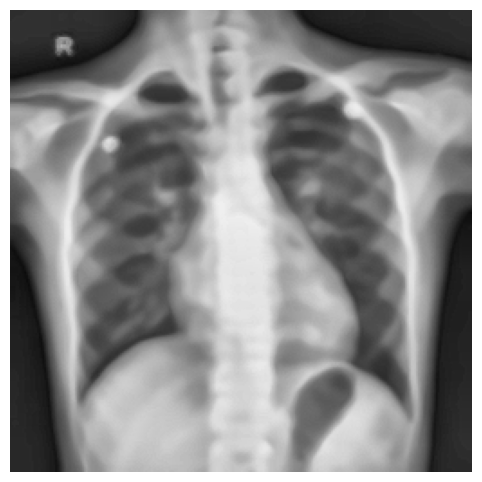

Generator output:


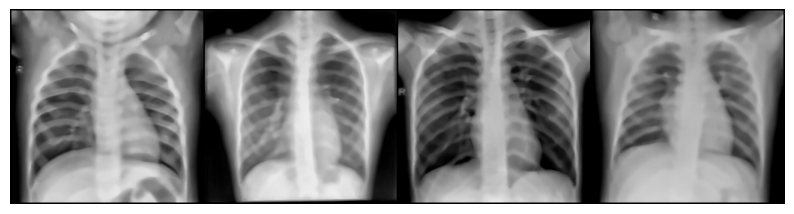

Ground truth (real HR):


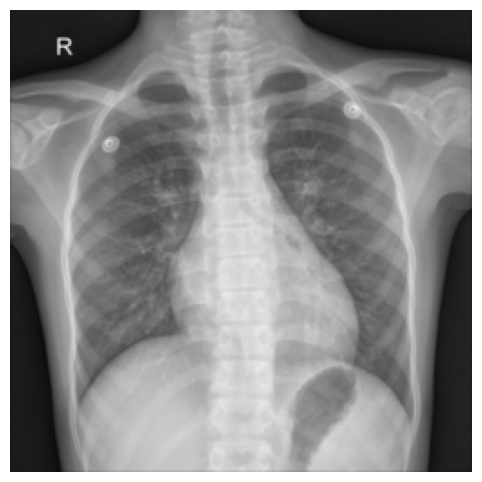

  -> new best, saved


FT-GAN Epoch 1:   0%|          | 0/285 [00:00<?, ?it/s]

Ep1 Step300 | D:0.6918 | G:6.8047 (adv:0.7123, L1:0.0609)
Ep1 Step350 | D:0.6870 | G:6.6608 (adv:0.7110, L1:0.0595)
Ep1 Step400 | D:0.6879 | G:7.4742 (adv:0.7050, L1:0.0677)
Ep1 Step450 | D:0.6861 | G:8.5400 (adv:0.6999, L1:0.0784)
Ep1 Step500 | D:0.6865 | G:6.4433 (adv:0.7057, L1:0.0574)
Ep1 Step550 | D:0.6825 | G:6.4129 (adv:0.7093, L1:0.0570)
== Epoch 1 | val L1: 0.0581 | val PSNR: 28.04 dB ==
Input (VAE-enhanced):


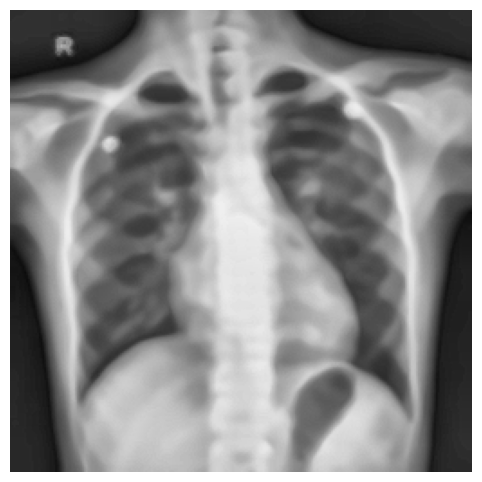

Generator output:


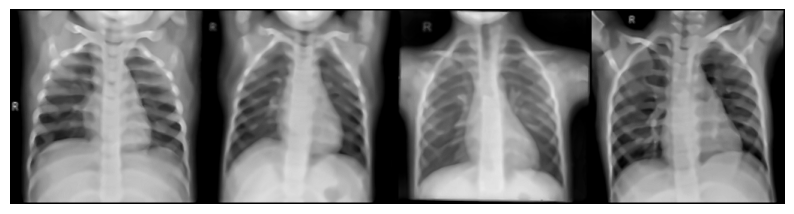

Ground truth (real HR):


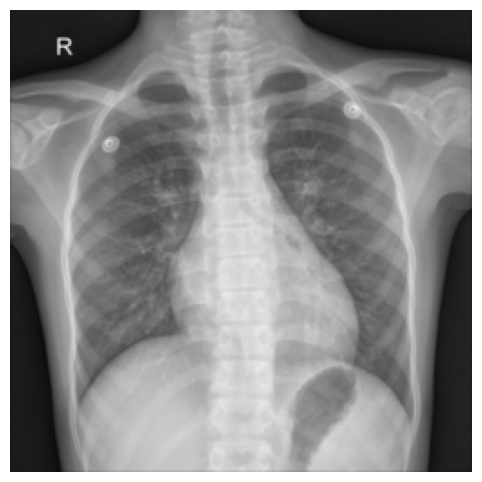

  -> new best, saved


FT-GAN Epoch 2:   0%|          | 0/285 [00:00<?, ?it/s]

Ep2 Step600 | D:0.6790 | G:5.7896 (adv:0.7162, L1:0.0507)
Ep2 Step650 | D:0.6796 | G:5.8208 (adv:0.7242, L1:0.0510)
Ep2 Step700 | D:0.6776 | G:6.7321 (adv:0.7047, L1:0.0603)
Ep2 Step750 | D:0.6752 | G:5.9042 (adv:0.7100, L1:0.0519)
Ep2 Step800 | D:0.6743 | G:6.3946 (adv:0.7236, L1:0.0567)
Ep2 Step850 | D:0.6750 | G:6.1066 (adv:0.7233, L1:0.0538)
== Epoch 2 | val L1: 0.0530 | val PSNR: 28.73 dB ==
Input (VAE-enhanced):


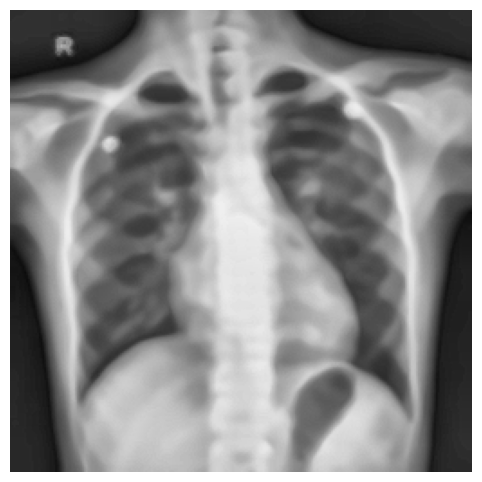

Generator output:


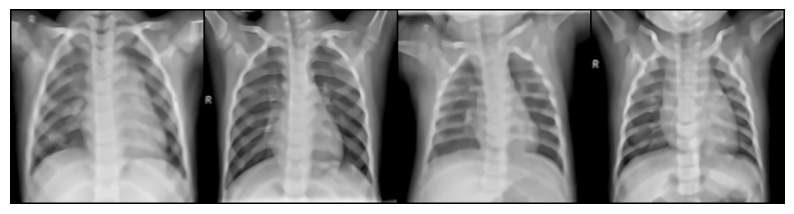

Ground truth (real HR):


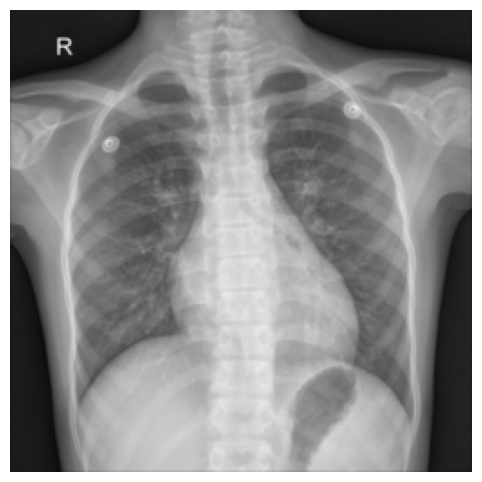

  -> new best, saved


FT-GAN Epoch 3:   0%|          | 0/285 [00:00<?, ?it/s]

Ep3 Step900 | D:0.6783 | G:6.8299 (adv:0.7226, L1:0.0611)
Ep3 Step950 | D:0.6780 | G:6.5784 (adv:0.7066, L1:0.0587)
Ep3 Step1000 | D:0.6780 | G:5.8888 (adv:0.7113, L1:0.0518)
Ep3 Step1050 | D:0.6684 | G:6.2686 (adv:0.7437, L1:0.0552)
Ep3 Step1100 | D:0.6584 | G:5.4841 (adv:0.7592, L1:0.0472)
== Epoch 3 | val L1: 0.0557 | val PSNR: 28.40 dB ==
Input (VAE-enhanced):


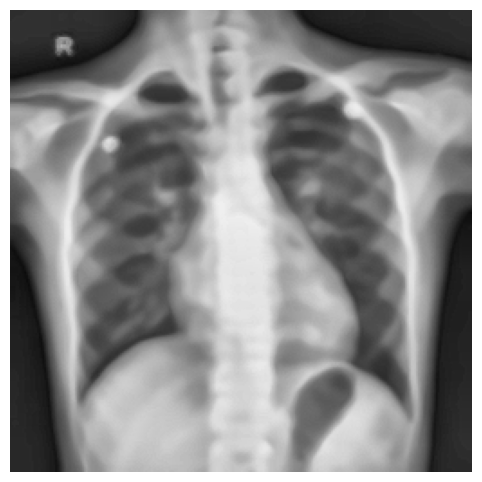

Generator output:


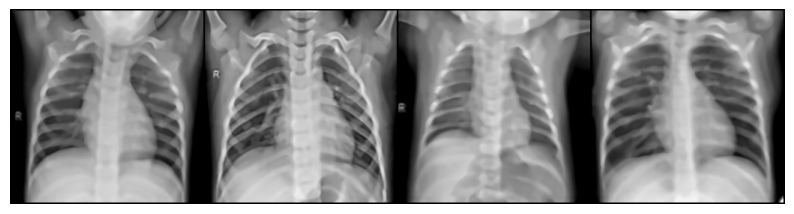

Ground truth (real HR):


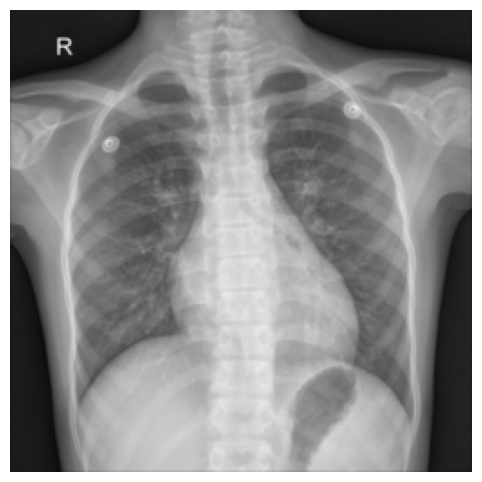

FT-GAN Epoch 4:   0%|          | 0/285 [00:00<?, ?it/s]

Ep4 Step1150 | D:0.6654 | G:6.4778 (adv:0.7340, L1:0.0574)
Ep4 Step1200 | D:0.6653 | G:5.9001 (adv:0.7091, L1:0.0519)
Ep4 Step1250 | D:0.6614 | G:5.9472 (adv:0.7342, L1:0.0521)
Ep4 Step1300 | D:0.6552 | G:5.5445 (adv:0.7353, L1:0.0481)
Ep4 Step1350 | D:0.6695 | G:5.4730 (adv:0.8323, L1:0.0464)
Ep4 Step1400 | D:0.6197 | G:7.5392 (adv:0.7640, L1:0.0678)
== Epoch 4 | val L1: 0.0502 | val PSNR: 29.14 dB ==
Input (VAE-enhanced):


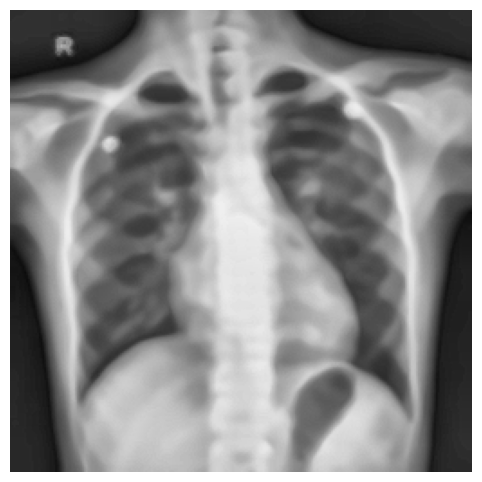

Generator output:


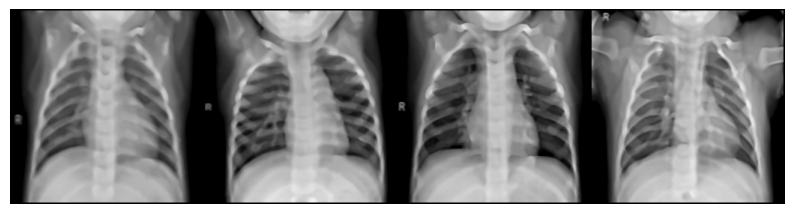

Ground truth (real HR):


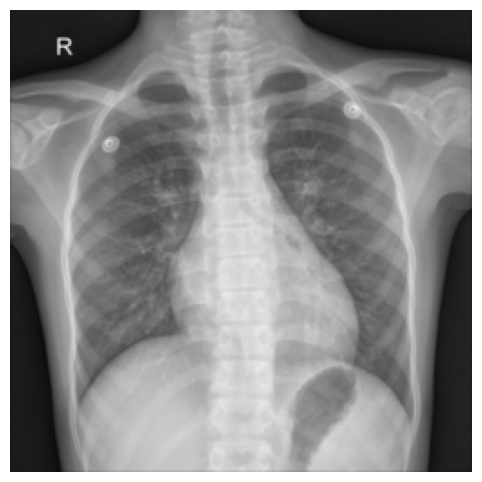

  -> new best, saved


FT-GAN Epoch 5:   0%|          | 0/285 [00:00<?, ?it/s]

Ep5 Step1450 | D:0.6560 | G:6.3165 (adv:0.7324, L1:0.0558)
Ep5 Step1500 | D:0.6313 | G:5.8482 (adv:0.7567, L1:0.0509)
Ep5 Step1550 | D:0.6327 | G:6.3362 (adv:0.8364, L1:0.0550)
Ep5 Step1600 | D:0.6338 | G:6.4710 (adv:0.7658, L1:0.0571)
Ep5 Step1650 | D:0.6448 | G:5.8896 (adv:0.7435, L1:0.0515)
Ep5 Step1700 | D:0.6344 | G:7.0501 (adv:0.7533, L1:0.0630)
== Epoch 5 | val L1: 0.0495 | val PSNR: 29.28 dB ==
Input (VAE-enhanced):


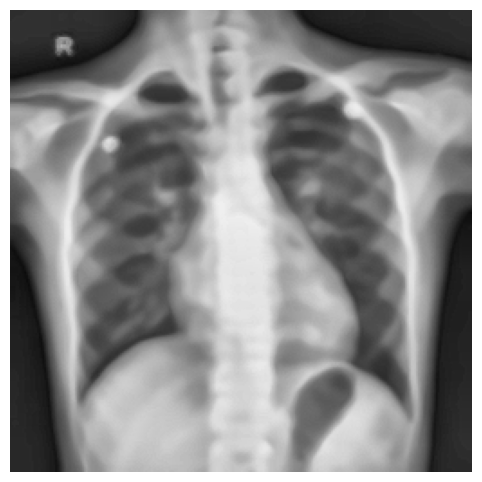

Generator output:


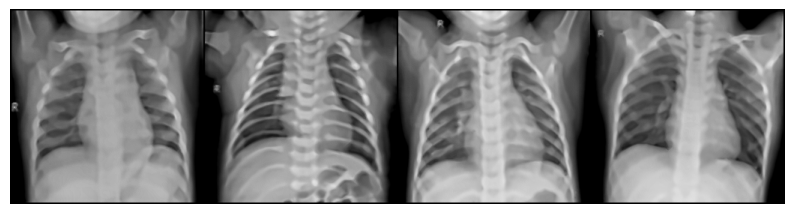

Ground truth (real HR):


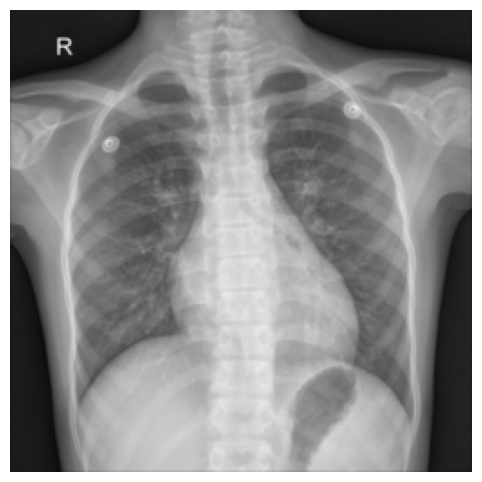

  -> new best, saved


FT-GAN Epoch 6:   0%|          | 0/285 [00:00<?, ?it/s]

Ep6 Step1750 | D:0.6423 | G:6.3024 (adv:0.6831, L1:0.0562)
Ep6 Step1800 | D:0.6221 | G:6.6218 (adv:0.8041, L1:0.0582)
Ep6 Step1850 | D:0.6288 | G:6.2280 (adv:0.7773, L1:0.0545)
Ep6 Step1900 | D:0.6082 | G:6.1140 (adv:0.8558, L1:0.0526)
Ep6 Step1950 | D:0.6324 | G:5.6480 (adv:0.7526, L1:0.0490)
== Epoch 6 | val L1: 0.0501 | val PSNR: 29.20 dB ==
Input (VAE-enhanced):


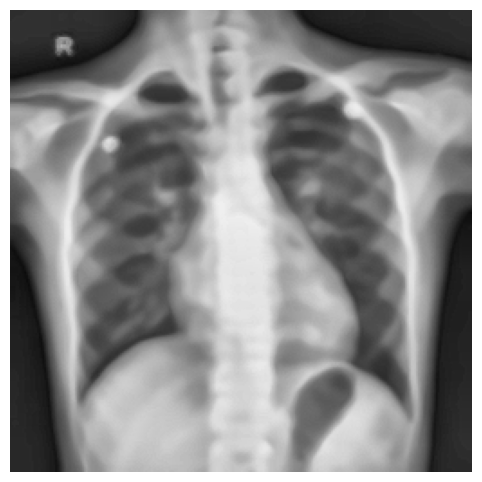

Generator output:


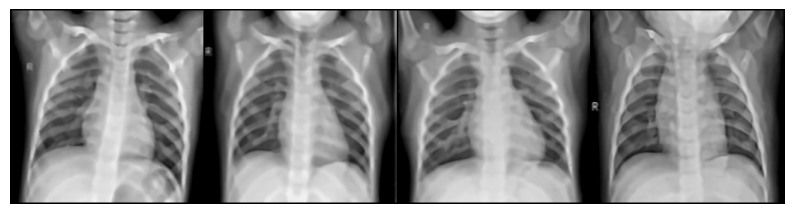

Ground truth (real HR):


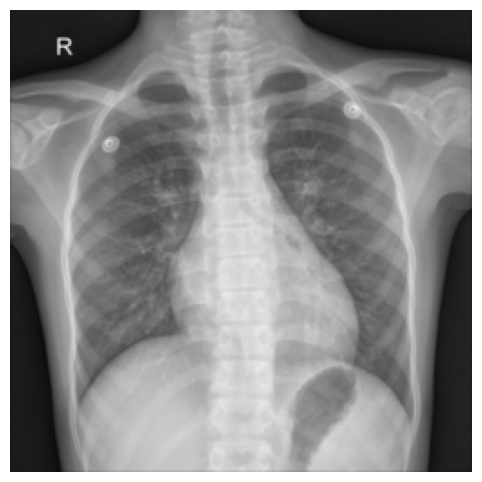

FT-GAN Epoch 7:   0%|          | 0/285 [00:00<?, ?it/s]

Ep7 Step2000 | D:0.6426 | G:5.8716 (adv:0.7314, L1:0.0514)
Ep7 Step2050 | D:0.6180 | G:5.5005 (adv:0.8019, L1:0.0470)
Ep7 Step2100 | D:0.6083 | G:6.4550 (adv:0.8201, L1:0.0563)
Ep7 Step2150 | D:0.6196 | G:5.8804 (adv:0.7523, L1:0.0513)
Ep7 Step2200 | D:0.6324 | G:5.9116 (adv:0.7767, L1:0.0513)
Ep7 Step2250 | D:0.6242 | G:6.8558 (adv:0.7667, L1:0.0609)
== Epoch 7 | val L1: 0.0503 | val PSNR: 29.15 dB ==
Input (VAE-enhanced):


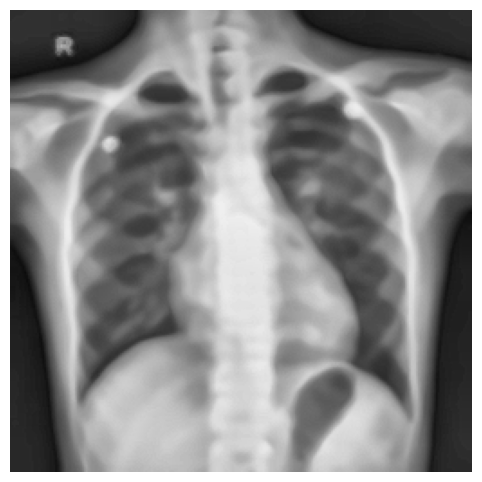

Generator output:


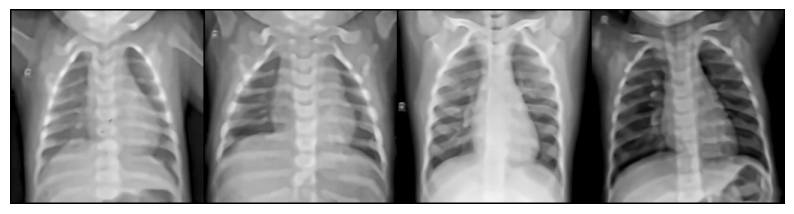

Ground truth (real HR):


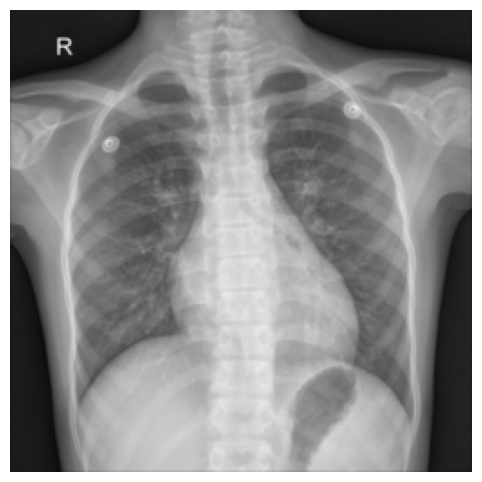

FT-GAN Epoch 8:   0%|          | 0/285 [00:00<?, ?it/s]

Ep8 Step2300 | D:0.6335 | G:5.3264 (adv:0.7640, L1:0.0456)
Ep8 Step2350 | D:0.6179 | G:6.2668 (adv:0.7320, L1:0.0553)
Ep8 Step2400 | D:0.6325 | G:6.3497 (adv:0.7916, L1:0.0556)
Ep8 Step2450 | D:0.5968 | G:5.8767 (adv:0.8614, L1:0.0502)
Ep8 Step2500 | D:0.6130 | G:5.5300 (adv:0.8137, L1:0.0472)
Ep8 Step2550 | D:0.5798 | G:6.7120 (adv:0.8261, L1:0.0589)
== Epoch 8 | val L1: 0.0580 | val PSNR: 28.12 dB ==
Input (VAE-enhanced):


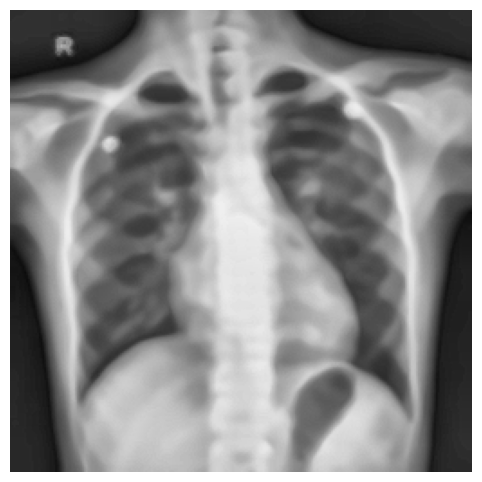

Generator output:


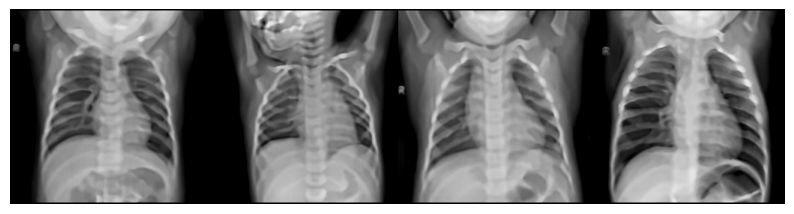

Ground truth (real HR):


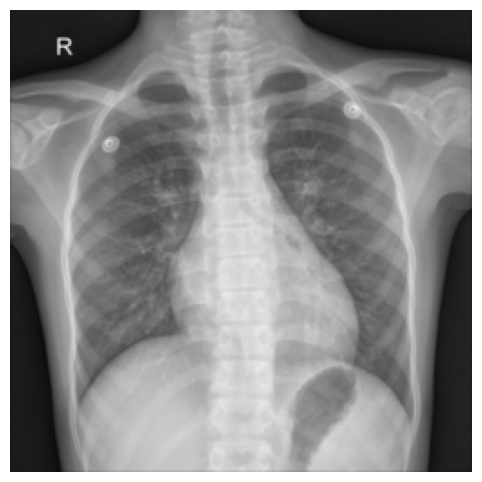

FT-GAN Epoch 9:   0%|          | 0/285 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [43]:
gen2 = UNet(input_dim, label_dim, hidden_channels).to(device)
base_ckpt = torch.load(BASE_GEN_PATH, map_location=device)
gen2.load_state_dict(base_ckpt['model_state_dict'])
print(f"Warm-started from base model, epoch {base_ckpt['epoch']}")

disc2 = PatchDiscriminator(input_dim + label_dim, disc_hidden_channels).to(device)
gen_opt2 = torch.optim.Adam(gen2.parameters(), lr=1e-5, betas=(0.5, 0.999))
disc_opt2 = torch.optim.Adam(disc2.parameters(), lr=2e-6, betas=(0.5, 0.999))

train_gan_v2(epochs=10, start_epoch=0)

Testing checkpoint from epoch 5
Val set — L1: 0.0495 | PSNR: 29.28 dB
Baseline (VAE-input vs HR, no model) PSNR: 22.24 dB
Input (VAE-enhanced):


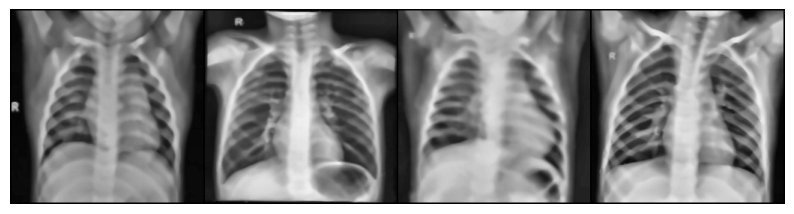

Generator output:


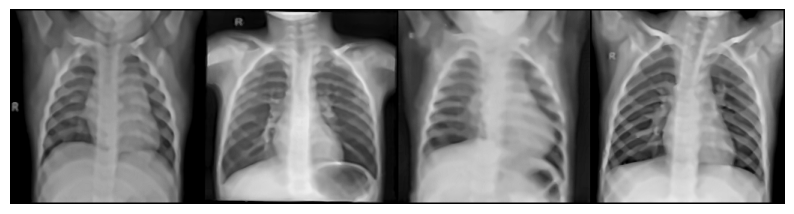

Ground truth (real HR):


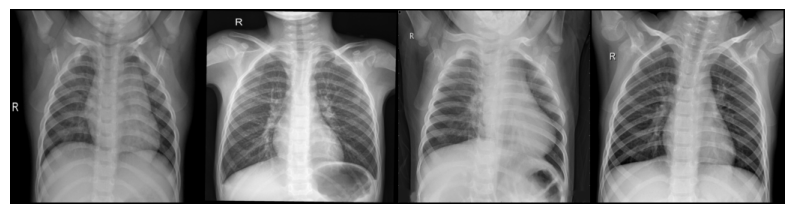

In [44]:
# Load your chosen best checkpoint (update epoch number in the print to whichever you kept)
final_ckpt = torch.load(GAN_V2_PATH, map_location=device)
gen2.load_state_dict(final_ckpt['gen_state_dict'])
gen2.eval()
print(f"Testing checkpoint from epoch {final_ckpt['epoch']}")

# --- 1. Full validation set metrics ---
total_l1, total_psnr, n = 0.0, 0.0, 0
with torch.no_grad():
    for lr_img, hr_img in val_loader2:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        pred = gen2(lr_img)
        total_l1 += recon_criterion(pred, hr_img).item()
        total_psnr += psnr(pred, hr_img).item()
        n += 1
print(f"Val set — L1: {total_l1/n:.4f} | PSNR: {total_psnr/n:.2f} dB")

# Compare against the no-model baseline (input vs target directly) for context
baseline_psnr, n2 = 0.0, 0
with torch.no_grad():
    for lr_img, hr_img in val_loader2:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        baseline_psnr += psnr(lr_img, hr_img).item()
        n2 += 1
print(f"Baseline (VAE-input vs HR, no model) PSNR: {baseline_psnr/n2:.2f} dB")

# --- 2. Visualize several individual examples ---
lr_batch, hr_batch = next(iter(val_loader2))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
with torch.no_grad():
    pred_batch = gen2(lr_batch)

print("Input (VAE-enhanced):")
show_tensor_images(lr_batch, num_images=4)
print("Generator output:")
show_tensor_images(pred_batch, num_images=4)
print("Ground truth (real HR):")
show_tensor_images(hr_batch, num_images=4)

Raw generator output    — L1: 0.0550 | PSNR: 28.52 dB
Input (VAE-enhanced):


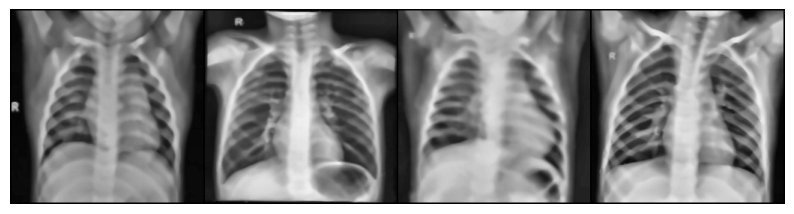

Generator output :


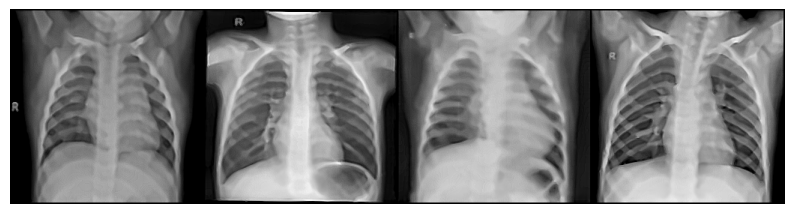

Ground truth (real HR):


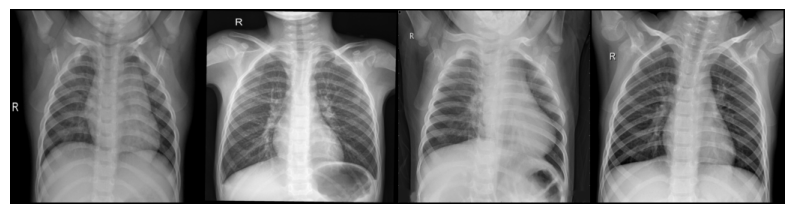

In [50]:
def unsharp_mask(img_tensor, amount=1.5, blur_sigma=1.0):
    '''
    Classic unsharp masking: sharpened = original + amount * (original - blurred).
    Operates directly on the [-1, 1] normalized tensor batch (no need to convert to PIL).
    '''
    kernel_size = int(2 * round(3 * blur_sigma) + 1)  # odd kernel covering ~3 sigma
    blurred = transforms.functional.gaussian_blur(img_tensor, kernel_size=kernel_size, sigma=blur_sigma)
    sharpened = img_tensor + amount * (img_tensor - blurred)
    return sharpened.clamp(-1, 1)  # keep values in the valid normalized range


# --- Apply post-processing sharpening to the generator's output ---
sharp_amount = 1.5   # higher = more aggressive sharpening; tune this
blur_sigma = 1.0

pred_sharp_batch = unsharp_mask(pred_batch, amount=sharp_amount, blur_sigma=blur_sigma)

# --- Metrics: raw generator output vs sharpened output, both against ground truth ---
raw_l1 = recon_criterion(pred_batch, hr_batch).item()
raw_psnr = psnr(pred_batch, hr_batch).item()
sharp_l1 = recon_criterion(pred_sharp_batch, hr_batch).item()
sharp_psnr = psnr(pred_sharp_batch, hr_batch).item()

print(f"Raw generator output    — L1: {raw_l1:.4f} | PSNR: {raw_psnr:.2f} dB")


print("Input (VAE-enhanced):")
show_tensor_images(lr_batch, num_images=4)

print("Generator output :")
show_tensor_images(pred_sharp_batch, num_images=4)
print("Ground truth (real HR):")
show_tensor_images(hr_batch, num_images=4)

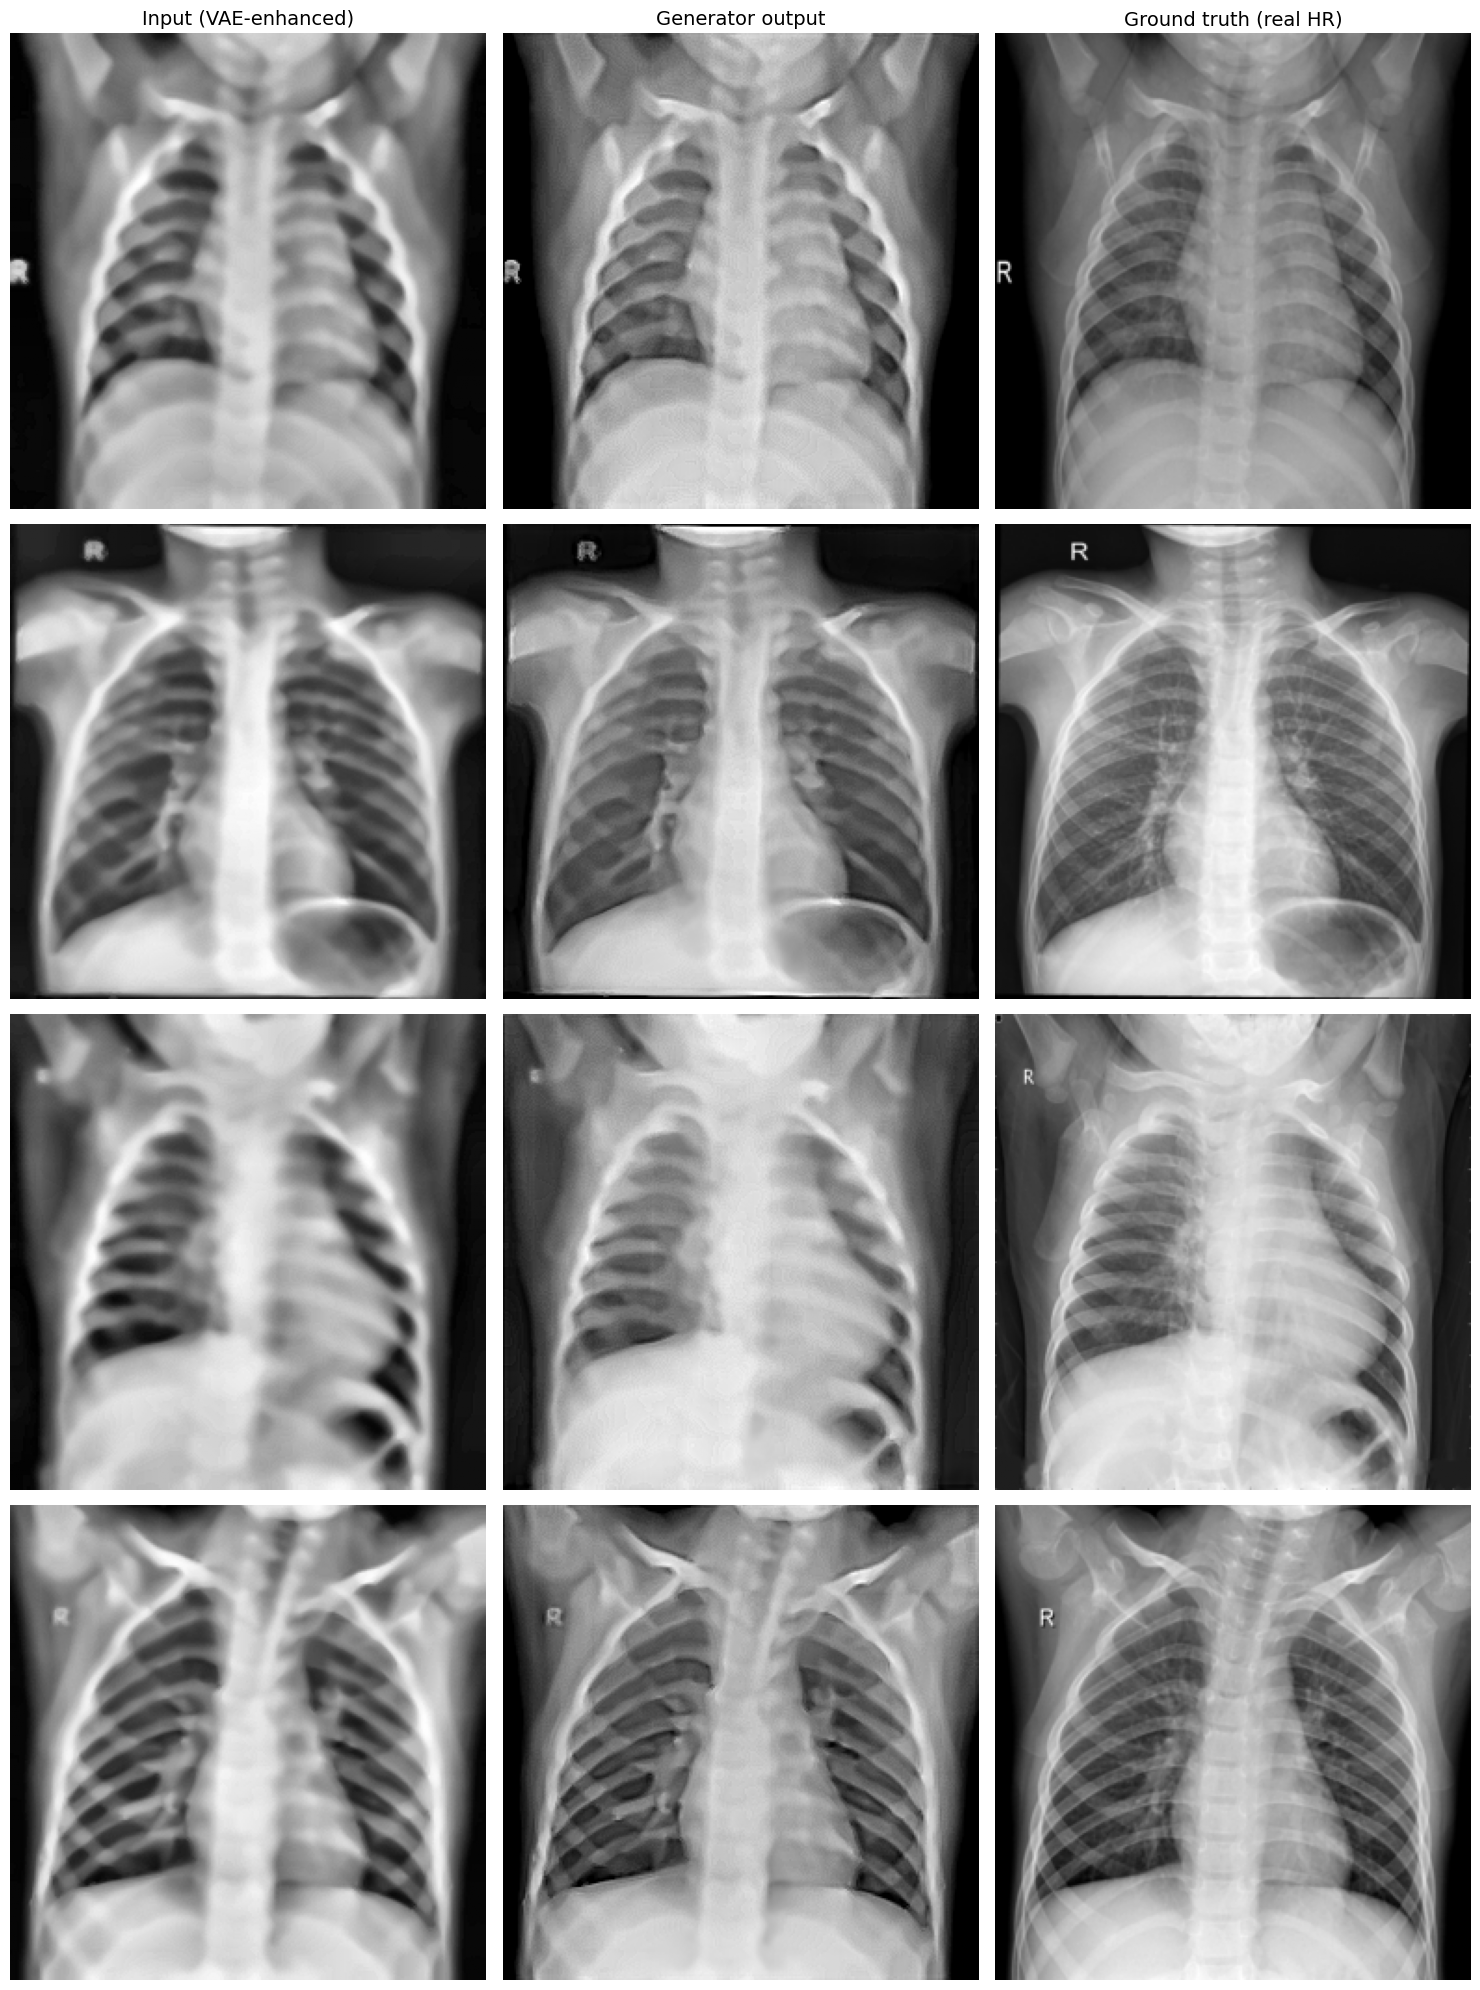

In [47]:
def unsharp_mask(img_tensor, amount=1.5, blur_sigma=1.0):
    kernel_size = int(2 * round(3 * blur_sigma) + 1)
    blurred = transforms.functional.gaussian_blur(img_tensor, kernel_size=kernel_size, sigma=blur_sigma)
    sharpened = img_tensor + amount * (img_tensor - blurred)
    return sharpened.clamp(-1, 1)


def show_comparison(lr_img, pred_img, hr_img, num_samples=4, size=(1, image_size, image_size)):
    def denorm(t):
        return ((t.detach().cpu() + 1) / 2).clamp(0, 1)
    lr_img, pred_img, hr_img = denorm(lr_img), denorm(pred_img), denorm(hr_img)
    num_samples = min(num_samples, lr_img.shape[0])
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = axes[None, :]
    titles = ['Input (VAE-enhanced)', 'Generator output', 'Ground truth (real HR)']
    for i in range(num_samples):
        for j, (img, title) in enumerate(zip([lr_img[i], pred_img[i], hr_img[i]], titles)):
            axes[i, j].imshow(img.squeeze(), cmap='gray')
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# Run it
lr_batch, hr_batch = next(iter(val_loader2))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
with torch.no_grad():
    pred_batch = gen2(lr_batch)

pred_sharp_batch = unsharp_mask(pred_batch, amount=1.5, blur_sigma=1.0)

show_comparison(lr_batch, pred_sharp_batch, hr_batch, num_samples=4)

Baseline (no model) PSNR : 23.18 dB
Raw generator output     — L1: 0.0533 | PSNR: 28.91 dB
Sharpened output         — L1: 0.0563 | PSNR: 28.49 dB


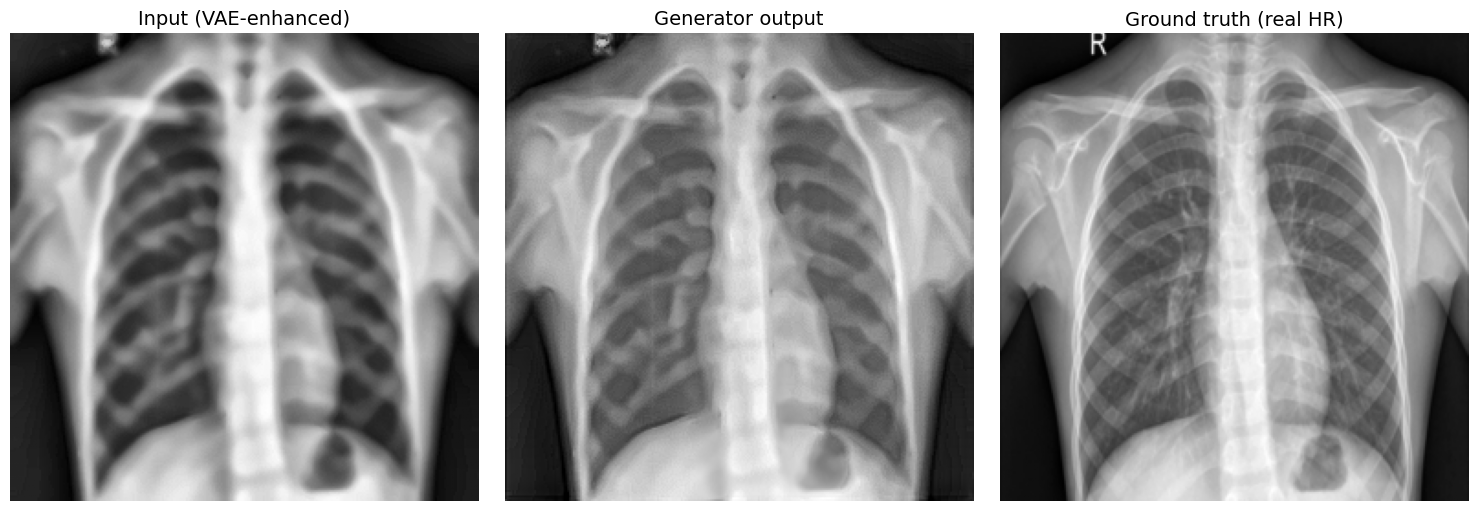

In [49]:
def unsharp_mask(img_tensor, amount=1.5, blur_sigma=1.0):
    kernel_size = int(2 * round(3 * blur_sigma) + 1)
    blurred = transforms.functional.gaussian_blur(img_tensor, kernel_size=kernel_size, sigma=blur_sigma)
    sharpened = img_tensor + amount * (img_tensor - blurred)
    return sharpened.clamp(-1, 1)


def test_single_image(lr_path, hr_path, image_size=256, sharp_amount=1.5, blur_sigma=1.0):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    lr_img = transform(Image.open(lr_path)).unsqueeze(0).to(device)
    hr_img = transform(Image.open(hr_path)).unsqueeze(0).to(device)

    gen2.eval()
    with torch.no_grad():
        pred_img = gen2(lr_img)

    pred_sharp_img = unsharp_mask(pred_img, amount=sharp_amount, blur_sigma=blur_sigma)

    raw_l1 = recon_criterion(pred_img, hr_img).item()
    raw_psnr = psnr(pred_img, hr_img).item()
    sharp_l1 = recon_criterion(pred_sharp_img, hr_img).item()
    sharp_psnr = psnr(pred_sharp_img, hr_img).item()
    baseline_p = psnr(lr_img, hr_img).item()

    print(f"Baseline (no model) PSNR : {baseline_p:.2f} dB")
    print(f"Raw generator output     — L1: {raw_l1:.4f} | PSNR: {raw_psnr:.2f} dB")
    print(f"Sharpened output         — L1: {sharp_l1:.4f} | PSNR: {sharp_psnr:.2f} dB")

    show_comparison(lr_img, pred_sharp_img, hr_img, num_samples=1)


lr_path = "/kaggle/input/datasets/raghavvbhat/enhanced-zip-images-from-vae-model/enhanced_images/IM-0001-0001.jpeg"
hr_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

test_single_image(lr_path, hr_path)

In [51]:
FINAL_MODEL_PATH = '/kaggle/working/final_generator.pth'

torch.save({
    'model_state_dict': gen2.state_dict(),
    'epoch': final_ckpt['epoch'],  # whichever epoch this checkpoint came from
}, FINAL_MODEL_PATH)

print(f"Saved final model to {FINAL_MODEL_PATH}")

Saved final model to /kaggle/working/final_generator.pth


In [52]:
print(f"Val set — L1: {total_l1/n:.4f} | PSNR: {total_psnr/n:.2f} dB")

Val set — L1: 0.0495 | PSNR: 29.28 dB
